# Notebook 15 — Results Analysis and Thesis Figures

**Purpose:** Read all experiment CSVs and produce the complete  
thesis-ready results: tables, figures, and statistical summaries.

**Research questions answered:**
```
RQ1: Which FSL method best generalizes to unseen users?
RQ2: Which FSL method best personalizes to new users?
RQ3: Does backbone choice matter more than method choice?
RQ4: Does the generalization→personalization trade-off hold across datasets?
```

**Outputs (saved to RESULTS_BASE/thesis_figures/):**
```
table_generalization.csv   — main generalization results
table_personalization.csv  — main personalization gain results
fig1_kshot_curves.png      — K-shot curves all methods × datasets
fig2_gain_heatmap.png      — personalization gain heatmap
fig3_backbone_effect.png   — backbone comparison
fig4_gen_vs_pers.png       — generalization vs personalization scatter
fig5_consistency.png       — per-user gain consistency
fig6_dataset_comparison.png — cross-dataset comparison
thesis_summary.txt         — plain-text summary of all key numbers
```

---
**Run after notebooks 12 and 13 have been run for all datasets.**  
Handles partial results gracefully — produces whatever is available.

## Cell 1 — Setup and Load All Results

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

from scipy import stats as scipy_stats

# ─── Figure output directory ──────────────────────────────────────────────────
FIG_DIR = os.path.join(RESULTS_BASE, 'thesis_figures')
os.makedirs(FIG_DIR, exist_ok=True)

# ─── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'     : 150,
    'font.size'      : 11,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# ─── Load all CSV results ─────────────────────────────────────────────────────
gen_frames  = []
pers_frames = []

for dataset in ALL_DATASETS:
    gen_csv  = os.path.join(RESULTS_BASE, f'generalization_{dataset}.csv')
    pers_csv = os.path.join(RESULTS_BASE, f'personalization_{dataset}.csv')

    if os.path.exists(gen_csv):
        df = pd.read_csv(gen_csv)
        df['dataset'] = dataset
        gen_frames.append(df)
        print(f'   ✅ Loaded gen CSV  for {dataset:<20} ({len(df):>5} rows)')
    else:
        print(f'   ❌ Missing gen CSV for {dataset}')

    if os.path.exists(pers_csv):
        df = pd.read_csv(pers_csv)
        df['dataset'] = dataset
        pers_frames.append(df)
        print(f'   ✅ Loaded pers CSV for {dataset:<20} ({len(df):>5} rows)')
    else:
        print(f'   ❌ Missing pers CSV for {dataset}')

df_gen  = pd.concat(gen_frames,  ignore_index=True) if gen_frames  else pd.DataFrame()
df_pers = pd.concat(pers_frames, ignore_index=True) if pers_frames else pd.DataFrame()

print(f'\n   Total gen rows  : {len(df_gen)}')
print(f'   Total pers rows : {len(df_pers)}')
print(f'   Figure dir      : {FIG_DIR}')

# Identify available datasets, backbones, methods
avail_datasets  = df_gen['dataset'].unique().tolist()  if not df_gen.empty  else []
avail_backbones = df_gen['backbone'].unique().tolist() if not df_gen.empty  else []
avail_methods   = df_gen['method'].unique().tolist()   if not df_gen.empty  else []
avail_methods   = [m for m in ALL_FSL_METHODS if m in avail_methods]  # keep order

DATASET_DISPLAY_NAMES = {
    'wisdm': 'WISDM',
    'cogage_atomic': 'CogAge (Atomic)',
    'cogage_composite': 'CogAge (Composite)',
    'humcare': 'HumCare',
}

print(f'\n   Datasets in results  : {avail_datasets}')
print(f'   Backbones in results : {avail_backbones}')
print(f'   Methods in results   : {avail_methods}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cpu
   NumPy    : 2.0.2
   CUDA     : False
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 streams | n_way=5
   humcar

## Cell 2 — Data Cleaning and Pivot Tables

In [2]:
def get_best_backbone_per_method_dataset(
    df       : pd.DataFrame,
    metric   : str,
    k_shot   : int,
    higher_is_better: bool = True,
) -> pd.DataFrame:
    """
    For each (dataset, method): pick the backbone with the best metric.
    Returns a DataFrame with one row per (dataset, method).
    """
    sub = df[df['k_shot'] == k_shot].copy()
    if sub.empty:
        return pd.DataFrame()

    if higher_is_better:
        idx = sub.groupby(['dataset', 'method'])[metric].idxmax()
    else:
        idx = sub.groupby(['dataset', 'method'])[metric].idxmin()

    return sub.loc[idx].reset_index(drop=True)


K_MAX = max(K_SHOTS)

# Clean column names — some CSVs may have slight variations
for df_ in [df_gen, df_pers]:
    if df_.empty: continue
    df_.columns = df_.columns.str.strip().str.lower()
    # Ensure numeric
    for col in ['k_shot', 'acc_mean', 'acc_before', 'acc_after', 'gain', 'ci95']:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors='coerce')

print('✅ Data cleaned')
if not df_gen.empty:
    print(f'   Gen columns   : {list(df_gen.columns)}')
if not df_pers.empty:
    print(f'   Pers columns  : {list(df_pers.columns)}')

✅ Data cleaned
   Gen columns   : ['dataset', 'backbone', 'method', 'eval_type', 'k_shot', 'seed', 'acc_mean', 'acc_std', 'ci95', 'macro_f1', 'n_episodes']
   Pers columns  : ['dataset', 'method', 'backbone', 'k_shot', 'subject', 'acc_before', 'acc_after', 'gain', 'ci95n_trials', 'ci95', 'n_test_users', 'seed', 'eval_type']


## Cell 3 — Table 1: Main Generalization Results

Rows = method × backbone. Columns = dataset × K-shot.  
This is the primary results table for the thesis.

In [3]:
if df_gen.empty:
    print('No generalization data available yet.')
else:
    print('══ TABLE 1: Generalization Accuracy ══')
    print('   Format: acc% ± CI95%')
    print()

    table_rows = []
    for dataset in avail_datasets:
        sub = df_gen[df_gen['dataset'] == dataset]
        for method in avail_methods:
            for backbone in avail_backbones:
                for k in K_SHOTS:
                    row_data = sub[
                        (sub['method'] == method) &
                        (sub['backbone'] == backbone) &
                        (sub['k_shot'] == k)
                    ]
                    if row_data.empty:
                        continue
                    r = row_data.iloc[0]
                    acc_col = 'acc_mean' if 'acc_mean' in r.index else 'acc_after'
                    table_rows.append({
                        'Dataset' : dataset,
                        'Method'  : method,
                        'Backbone': backbone,
                        'K'       : int(k),
                        'Acc'     : float(r.get(acc_col, 0)),
                        'CI95'    : float(r.get('ci95', 0)),
                    })

    df_table1 = pd.DataFrame(table_rows)

    if not df_table1.empty:
        # Pivot: rows = Method+Backbone, cols = Dataset+K
        df_table1['Label'] = (
            df_table1['Acc'].apply(lambda x: f'{x*100:.1f}') +
            '±' +
            df_table1['CI95'].apply(lambda x: f'{x*100:.1f}')
        )
        pivot = df_table1.pivot_table(
            index   = ['Method', 'Backbone'],
            columns = ['Dataset', 'K'],
            values  = 'Label',
            aggfunc = 'first',
        )
        print(pivot.to_string())

        # Save
        t1_path = os.path.join(FIG_DIR, 'table_generalization.csv')
        df_table1.to_csv(t1_path, index=False)
        print(f'\nSaved: {t1_path}')

        # Best config per dataset
        print(f'\n── Best generalization config per dataset (K={K_MAX}) ──')
        for dataset in avail_datasets:
            sub_k = df_table1[
                (df_table1['Dataset'] == dataset) & (df_table1['K'] == K_MAX)
            ]
            if sub_k.empty: continue
            best = sub_k.loc[sub_k['Acc'].idxmax()]
            print(f'   {dataset:<22}: {best["Method"]} + {best["Backbone"]} '
                  f'→ {best["Acc"]*100:.2f}% ±{best["CI95"]*100:.2f}%')

══ TABLE 1: Generalization Accuracy ══
   Format: acc% ± CI95%

Dataset              cogage_atomic                     cogage_composite                       humcare                         wisdm                    
K                               1         5         10               1         5         10        1         5         10        1         5         10
Method   Backbone                                                                                                                                      
maml     cnn              64.1±1.5  82.7±1.2  86.4±0.9              NaN       NaN       NaN       NaN       NaN       NaN  60.6±1.6  78.8±1.4  83.3±1.3
         lstm             65.6±1.8  78.1±1.2  79.8±1.2              NaN       NaN       NaN       NaN       NaN       NaN  67.2±1.6  78.5±1.4  81.3±1.2
         transformer      72.8±1.6  85.0±1.1  87.3±0.9              NaN       NaN       NaN       NaN       NaN       NaN  64.9±1.8  78.1±1.5  81.2±1.3
protonet cnn            

## Cell 4 — Table 2: Main Personalization Gain Results

In [4]:
if df_pers.empty:
    print('No personalization data available yet.')
else:
    print('══ TABLE 2: Personalization Gain ══')
    print('   Format: gain% ± CI95%  (+ = K-shot helped)')
    print()

    table_rows2 = []
    for dataset in avail_datasets:
        sub = df_pers[df_pers['dataset'] == dataset]
        for method in avail_methods:
            for backbone in avail_backbones:
                for k in K_SHOTS:
                    row_data = sub[
                        (sub['method'] == method) &
                        (sub['backbone'] == backbone) &
                        (sub['k_shot'] == k)
                    ]
                    if row_data.empty:
                        continue
                    # Average over per-user rows if multiple exist
                    mean_gain = row_data['gain'].mean()
                    mean_bef  = row_data['acc_before'].mean()
                    mean_aft  = row_data['acc_after'].mean()
                    ci95      = (
                        row_data['ci95'].mean() if 'ci95' in row_data.columns
                        else 1.96*row_data['gain'].std()/max(np.sqrt(len(row_data)),1)
                    )
                    table_rows2.append({
                        'Dataset'    : dataset,
                        'Method'     : method,
                        'Backbone'   : backbone,
                        'K'          : int(k),
                        'AccBefore'  : float(mean_bef),
                        'AccAfter'   : float(mean_aft),
                        'Gain'       : float(mean_gain),
                        'CI95'       : float(ci95),
                    })

    df_table2 = pd.DataFrame(table_rows2)

    if not df_table2.empty:
        sign = lambda x: '+' if x >= 0 else ''
        df_table2['Label'] = df_table2.apply(
            lambda r: f'{sign(r.Gain)}{r.Gain*100:.1f}±{r.CI95*100:.1f}', axis=1
        )
        pivot2 = df_table2.pivot_table(
            index   = ['Method', 'Backbone'],
            columns = ['Dataset', 'K'],
            values  = 'Label',
            aggfunc = 'first',
        )
        print(pivot2.to_string())

        t2_path = os.path.join(FIG_DIR, 'table_personalization.csv')
        df_table2.to_csv(t2_path, index=False)
        print(f'\nSaved: {t2_path}')

        print(f'\n── Best personalization config per dataset (K={K_MAX}) ──')
        for dataset in avail_datasets:
            sub_k = df_table2[
                (df_table2['Dataset'] == dataset) & (df_table2['K'] == K_MAX)
            ]
            if sub_k.empty: continue
            best = sub_k.loc[sub_k['Gain'].idxmax()]
            print(f'   {dataset:<22}: {best["Method"]} + {best["Backbone"]} '
                  f'→ gain={best["Gain"]*100:+.2f}%')

══ TABLE 2: Personalization Gain ══
   Format: gain% ± CI95%  (+ = K-shot helped)

Dataset                   wisdm                      
K                            1          5          10
Method   Backbone                                    
maml     cnn          +25.0±nan  +30.5±nan  +31.1±nan
         lstm         +17.3±nan  +27.0±nan  +28.8±nan
         transformer  +27.4±nan  +34.9±nan  +35.8±nan
protonet cnn          +17.8±nan  +24.1±nan  +24.8±nan
         lstm         +18.9±nan  +26.7±nan  +27.5±nan
         transformer  +15.7±nan  +21.8±nan  +22.6±nan
supcon   cnn          +17.8±nan  +24.1±nan  +25.0±nan
         lstm         +16.6±nan  +24.4±nan  +25.5±nan
         transformer  +12.7±nan  +18.3±nan  +18.9±nan

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/table_personalization.csv

── Best personalization config per dataset (K=10) ──
   wisdm                 : maml + transformer → gain=+35.84%


## Cell 5 — Figure 1: K-Shot Generalization Curves

One panel per dataset. Each panel shows all methods with the best backbone  
(selected as the backbone that achieves highest average accuracy across K).  
This is the main generalization figure for the thesis.

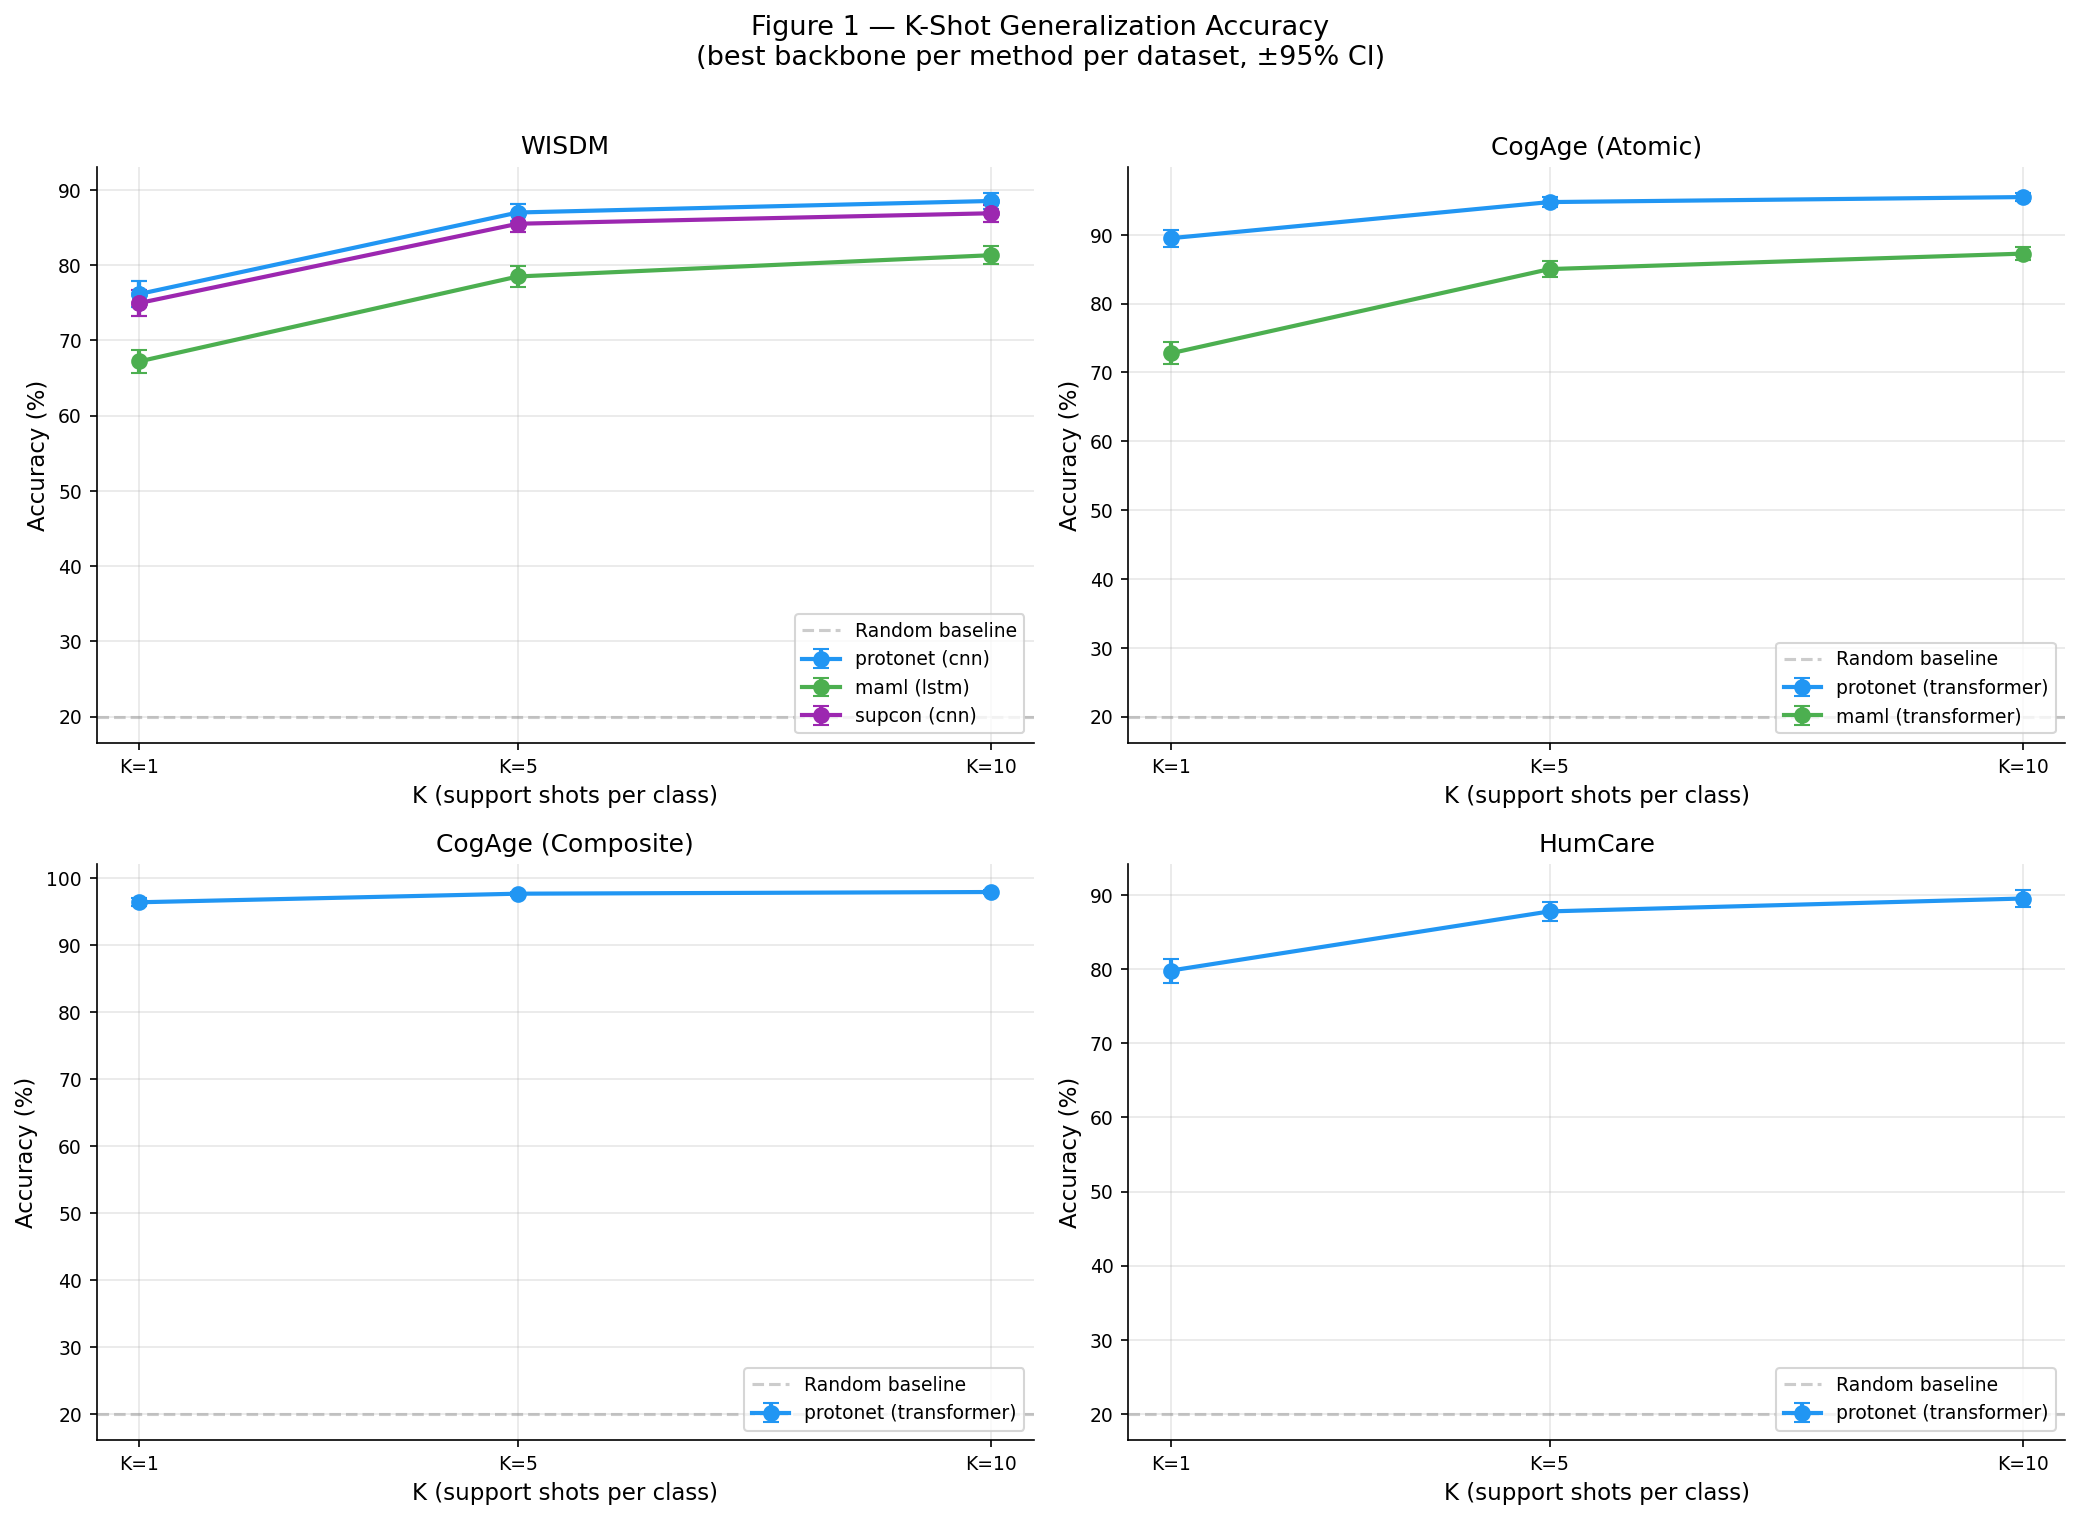

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/fig1_kshot_generalization.png


In [5]:
if df_gen.empty:
    print('No generalization data — skipping Figure 1')
else:
    n_ds   = len(avail_datasets)
    n_cols = min(n_ds, 2)
    n_rows = (n_ds + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(7*n_cols, 5*n_rows),
                             squeeze=False)

    for ax_idx, dataset in enumerate(avail_datasets):
        row, col = divmod(ax_idx, n_cols)
        ax = axes[row][col]

        sub_ds = df_gen[df_gen['dataset'] == dataset]

        # For each method pick the best backbone (highest mean acc across K)
        for method in avail_methods:
            sub_m = sub_ds[sub_ds['method'] == method]
            if sub_m.empty:
                continue

            # Best backbone for this method on this dataset
            bb_mean = (
                sub_m.groupby('backbone')['acc_mean'].mean()
                if 'acc_mean' in sub_m.columns
                else sub_m.groupby('backbone')['acc_after'].mean()
            )
            best_bb = bb_mean.idxmax()
            sub_mb  = sub_m[sub_m['backbone'] == best_bb].sort_values('k_shot')

            ks    = sub_mb['k_shot'].tolist()
            acc_col = 'acc_mean' if 'acc_mean' in sub_mb.columns else 'acc_after'
            accs  = (sub_mb[acc_col] * 100).tolist()
            ci95s = (sub_mb['ci95'] * 100).tolist() if 'ci95' in sub_mb.columns else [0]*len(ks)

            ax.errorbar(
                ks, accs, yerr=ci95s,
                label=f'{method} ({best_bb})',
                color=METHOD_COLORS.get(method, 'gray'),
                marker='o', linewidth=2, markersize=7, capsize=4,
            )

        ax.axhline(y=100/DATASET_CONFIGS[dataset]['n_way'],
                   linestyle='--', color='gray', alpha=0.4,
                   label='Random baseline')
        ax.set_xticks(K_SHOTS)
        ax.set_xticklabels([f'K={k}' for k in K_SHOTS])
        ax.set_xlabel('K (support shots per class)')
        ax.set_ylabel('Accuracy (%)')
        ax.set_title(f'{DATASET_DISPLAY_NAMES.get(dataset, dataset)}')
        ax.legend(loc='lower right')

    # Hide unused panels
    for ax_idx in range(len(avail_datasets), n_rows*n_cols):
        row, col = divmod(ax_idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(
        'Figure 1 — K-Shot Generalization Accuracy\n'
        '(best backbone per method per dataset, ±95% CI)',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    p = os.path.join(FIG_DIR, 'fig1_kshot_generalization.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

## Cell 6 — Figure 2: Personalization Gain Heatmap

Method × dataset heatmap of mean personalization gain at K=max.  
Uses best backbone per (method, dataset) combination.

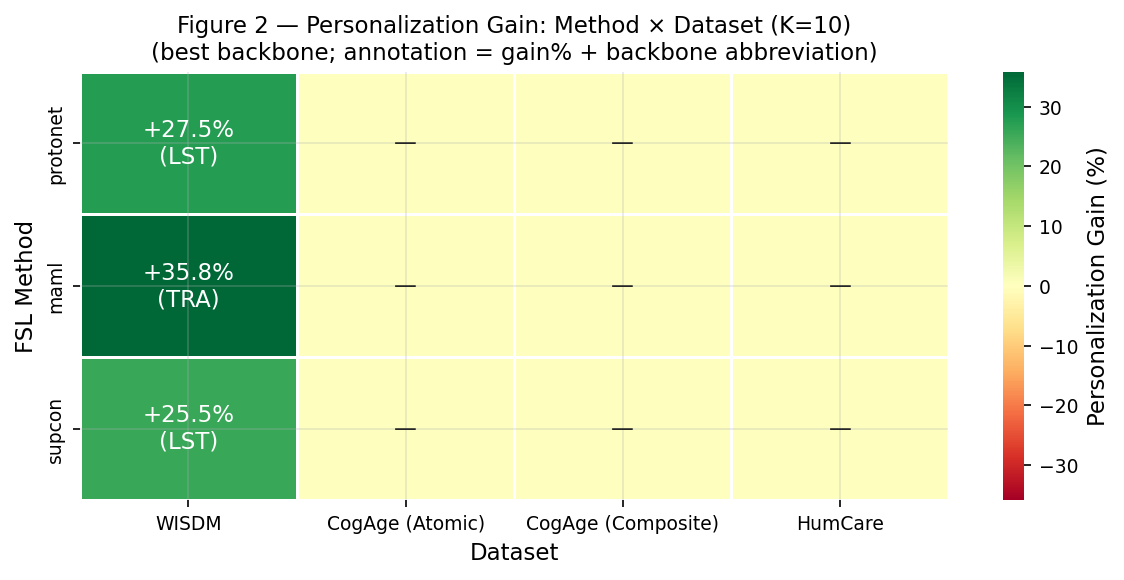

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/fig2_gain_heatmap.png


In [6]:
if df_pers.empty:
    print('No personalization data — skipping Figure 2')
else:
    # Best backbone per (method, dataset) by highest gain at K_MAX
    sub_kmax = df_pers[df_pers['k_shot'] == K_MAX]

    gain_matrix   = np.full((len(avail_methods), len(avail_datasets)), np.nan)
    best_bb_matrix= [['—']*len(avail_datasets) for _ in avail_methods]

    for i, method in enumerate(avail_methods):
        for j, dataset in enumerate(avail_datasets):
            sub = sub_kmax[
                (sub_kmax['method'] == method) &
                (sub_kmax['dataset'] == dataset)
            ]
            if sub.empty:
                continue
            # Pick best backbone
            bb_gains = sub.groupby('backbone')['gain'].mean()
            best_bb  = bb_gains.idxmax()
            best_val = bb_gains.max()
            gain_matrix[i, j]    = best_val * 100
            best_bb_matrix[i][j] = best_bb[:3].upper()   # abbreviate

    if not np.all(np.isnan(gain_matrix)):
        fig, ax = plt.subplots(figsize=(max(6, len(avail_datasets)*2), 4))
        vabs    = np.nanmax(np.abs(gain_matrix))

        # Annotation: gain + best backbone abbreviation
        annot = np.full_like(gain_matrix, '—', dtype=object)
        for i in range(len(avail_methods)):
            for j in range(len(avail_datasets)):
                if not np.isnan(gain_matrix[i,j]):
                    g = gain_matrix[i,j]
                    annot[i,j] = f'{g:+.1f}%\n({best_bb_matrix[i][j]})'

        sns.heatmap(
            np.nan_to_num(gain_matrix),
            xticklabels=[DATASET_DISPLAY_NAMES.get(d, d) for d in avail_datasets],
            yticklabels=avail_methods,
            annot=annot, fmt='',
            cmap='RdYlGn', center=0, vmin=-vabs, vmax=vabs,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Personalization Gain (%)'},
        )
        ax.set_title(
            f'Figure 2 — Personalization Gain: Method × Dataset (K={K_MAX})\n'
            f'(best backbone; annotation = gain% + backbone abbreviation)',
            fontsize=11
        )
        ax.set_xlabel('Dataset')
        ax.set_ylabel('FSL Method')
        plt.tight_layout()
        p = os.path.join(FIG_DIR, 'fig2_gain_heatmap.png')
        plt.savefig(p, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {p}')
    else:
        print('Not enough data for heatmap')

## Cell 7 — Figure 3: Backbone Effect Analysis

RQ3: Does backbone choice matter more than method choice?  
For each method: box of accuracies across backbones and datasets.  
Narrow box = method is backbone-agnostic.

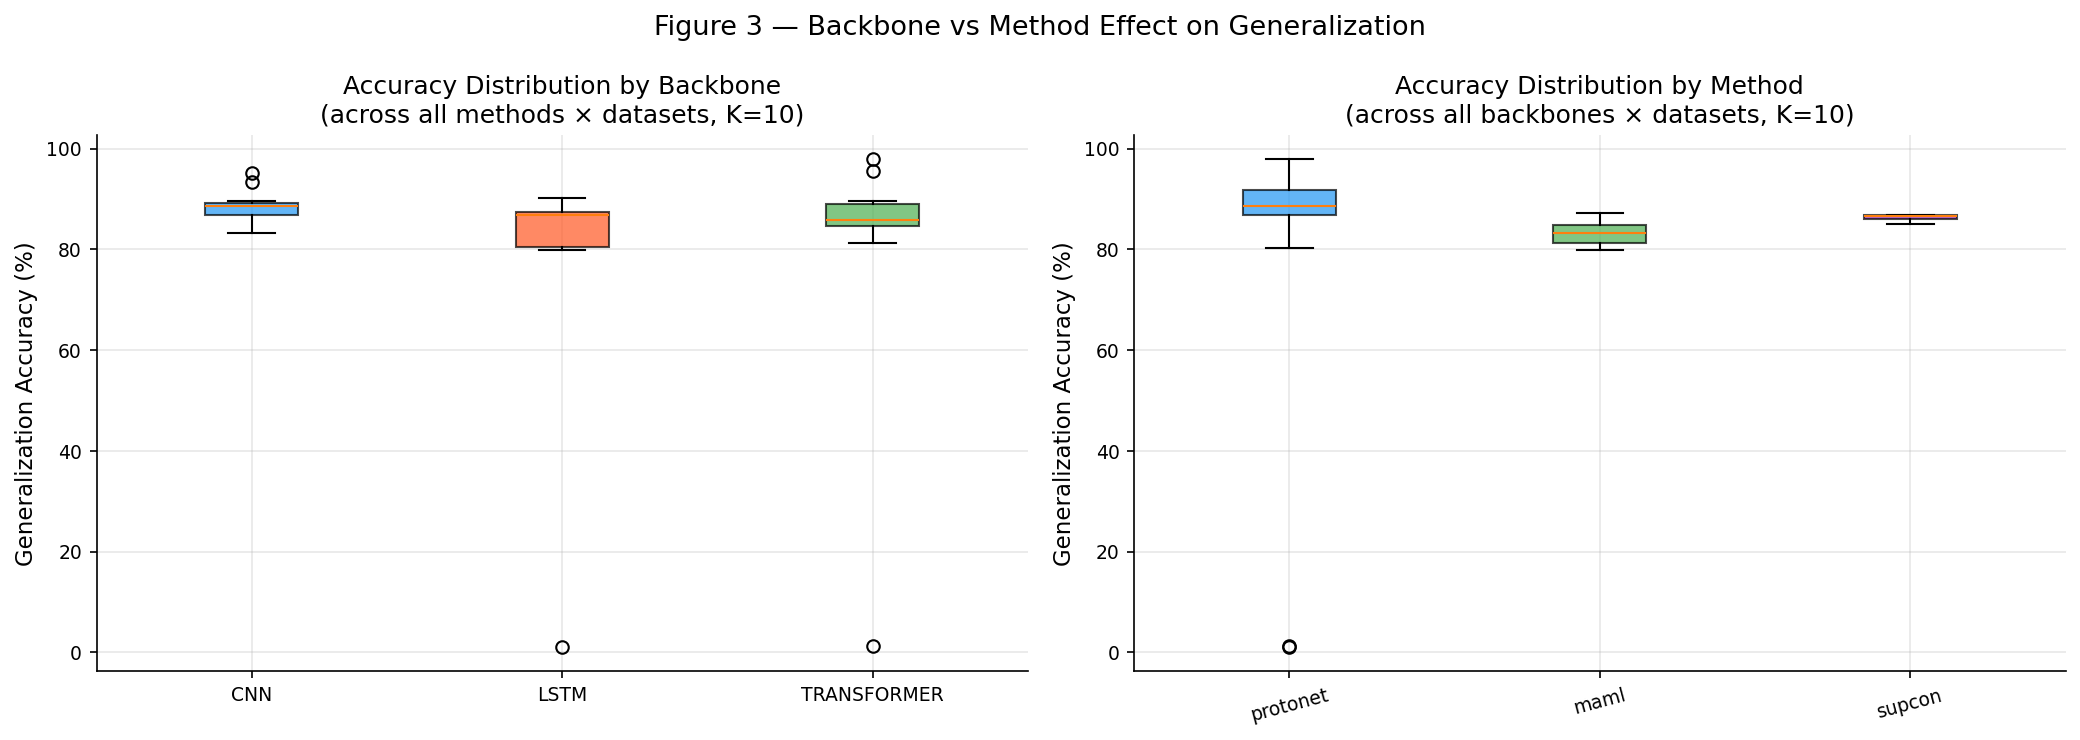

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/fig3_backbone_vs_method_effect.png

RQ3 Statistical test:
   ANOVA across backbones : F=0.860, p=0.4337
   ANOVA across methods   : F=0.216, p=0.8074
   Interpretation: Neither backbone nor method has significant effect (p>0.05)


In [7]:
if df_gen.empty:
    print('No generalization data — skipping Figure 3')
else:
    sub_kmax = df_gen[df_gen['k_shot'] == K_MAX].copy()
    acc_col  = 'acc_mean' if 'acc_mean' in sub_kmax.columns else 'acc_after'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel A: Accuracy distribution per backbone ───────────────────────────
    ax = axes[0]
    plot_data   = []
    plot_labels = []
    for bb in avail_backbones:
        vals = sub_kmax[sub_kmax['backbone'] == bb][acc_col].dropna().tolist()
        if vals:
            plot_data.append([v*100 for v in vals])
            plot_labels.append(bb.upper())

    if plot_data:
        bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True)
        colors_bb = ['#2196F3', '#FF5722', '#4CAF50']
        for patch, col in zip(bp['boxes'], colors_bb[:len(plot_data)]):
            patch.set_facecolor(col)
            patch.set_alpha(0.7)
        ax.set_ylabel('Generalization Accuracy (%)')
        ax.set_title('Accuracy Distribution by Backbone\n(across all methods × datasets, K=10)')

    # ── Panel B: Accuracy distribution per method ─────────────────────────────
    ax = axes[1]
    plot_data2   = []
    plot_labels2 = []
    for method in avail_methods:
        vals = sub_kmax[sub_kmax['method'] == method][acc_col].dropna().tolist()
        if vals:
            plot_data2.append([v*100 for v in vals])
            plot_labels2.append(method)

    if plot_data2:
        bp2 = ax.boxplot(plot_data2, labels=plot_labels2, patch_artist=True)
        for patch, method in zip(bp2['boxes'], avail_methods):
            patch.set_facecolor(METHOD_COLORS.get(method, 'gray'))
            patch.set_alpha(0.7)
        ax.set_ylabel('Generalization Accuracy (%)')
        ax.set_title('Accuracy Distribution by Method\n(across all backbones × datasets, K=10)')
        ax.tick_params(axis='x', rotation=15)

    fig.suptitle('Figure 3 — Backbone vs Method Effect on Generalization', fontsize=13)
    plt.tight_layout()
    p = os.path.join(FIG_DIR, 'fig3_backbone_vs_method_effect.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

    # Statistical answer to RQ3
    if plot_data and plot_data2 and len(plot_data) >= 2 and len(plot_data2) >= 2:
        # Variance of accuracy across backbones vs across methods
        all_bb_vals     = [v for group in plot_data  for v in group]
        all_method_vals = [v for group in plot_data2 for v in group]
        bb_labels_all   = [plot_labels[i]  for i,g in enumerate(plot_data)  for _ in g]
        m_labels_all    = [plot_labels2[i] for i,g in enumerate(plot_data2) for _ in g]

        # One-way ANOVA: is there significant variance across backbones/methods?
        bb_groups     = [np.array([v for v,l in zip(all_bb_vals, bb_labels_all) if l==b])
                         for b in plot_labels]
        method_groups = [np.array([v for v,l in zip(all_method_vals, m_labels_all) if l==m])
                         for m in plot_labels2]

        if all(len(g)>1 for g in bb_groups) and len(bb_groups)>1:
            f_bb, p_bb = scipy_stats.f_oneway(*bb_groups)
            print(f'\nRQ3 Statistical test:')
            print(f'   ANOVA across backbones : F={f_bb:.3f}, p={p_bb:.4f}')
            if all(len(g)>1 for g in method_groups) and len(method_groups)>1:
                f_m, p_m = scipy_stats.f_oneway(*method_groups)
                print(f'   ANOVA across methods   : F={f_m:.3f}, p={p_m:.4f}')
                print(f'   Interpretation: ', end='')
                if p_bb < 0.05 and p_m < 0.05:
                    if f_bb > f_m:
                        print('Backbone choice matters MORE than method choice')
                    else:
                        print('Method choice matters MORE than backbone choice')
                elif p_bb < 0.05:
                    print('Only backbone choice has significant effect')
                elif p_m < 0.05:
                    print('Only method choice has significant effect')
                else:
                    print('Neither backbone nor method has significant effect (p>0.05)')

## Cell 8 — Figure 4: Generalization vs Personalization Trade-off

RQ4: Does high generalization guarantee high personalization gain?  
One panel per dataset. Each point = one (method, backbone) combination.

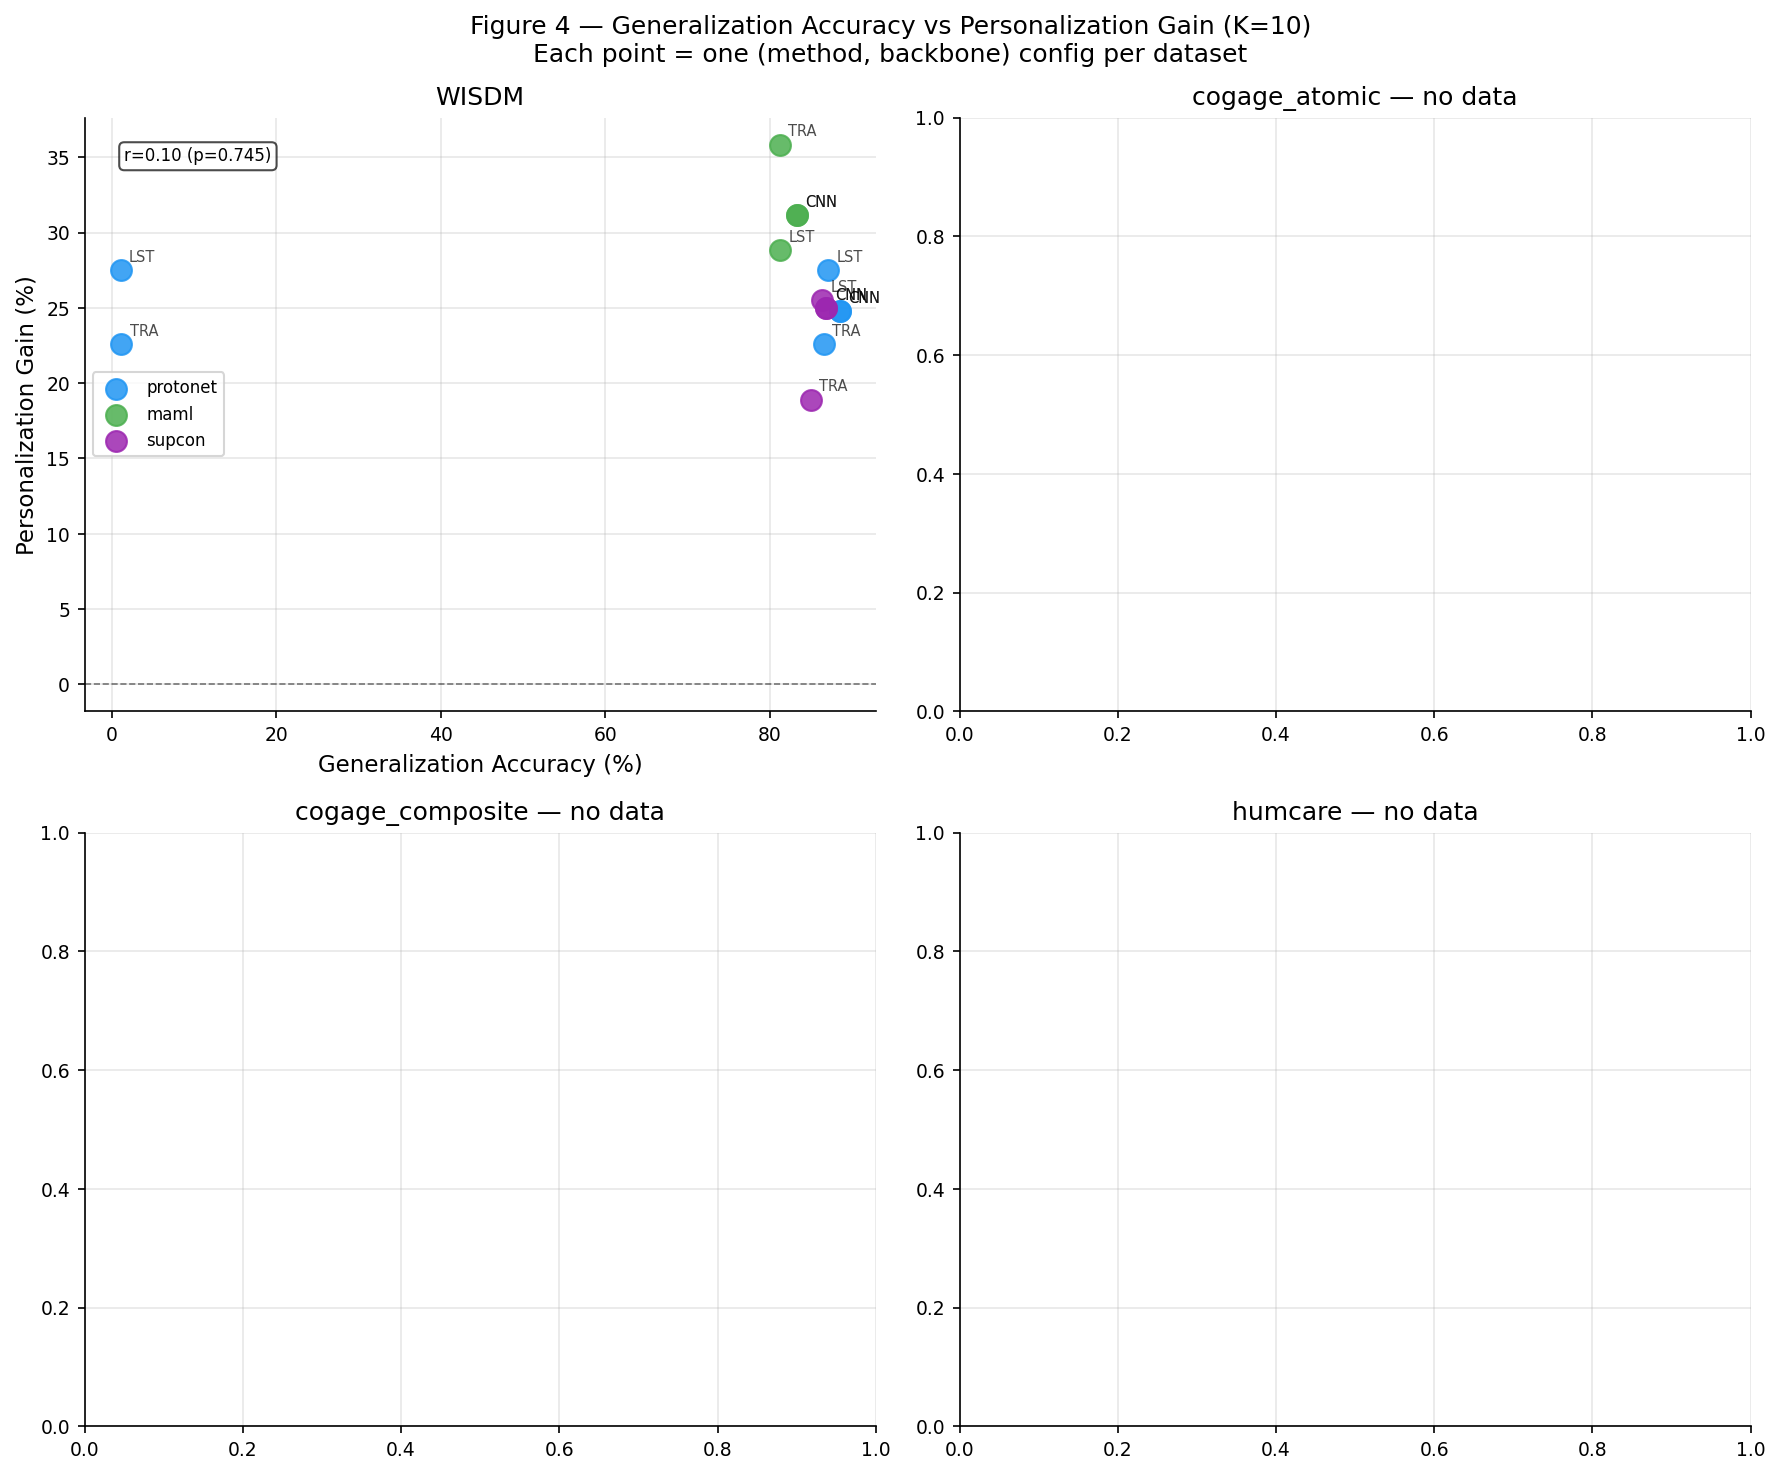

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/fig4_gen_vs_pers_tradeoff.png


In [8]:
if df_gen.empty or df_pers.empty:
    print('Need both gen and pers data — skipping Figure 4')
else:
    n_ds   = len(avail_datasets)
    n_cols = min(n_ds, 2)
    n_rows = (n_ds + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6*n_cols, 5*n_rows),
                             squeeze=False)

    acc_col = 'acc_mean' if 'acc_mean' in df_gen.columns else 'acc_after'

    for ax_idx, dataset in enumerate(avail_datasets):
        row, col = divmod(ax_idx, n_cols)
        ax = axes[row][col]

        gen_sub  = df_gen[
            (df_gen['dataset']==dataset) & (df_gen['k_shot']==K_MAX)
        ][['method','backbone', acc_col]].rename(columns={acc_col:'gen_acc'})

        pers_sub = df_pers[
            (df_pers['dataset']==dataset) & (df_pers['k_shot']==K_MAX)
        ].groupby(['method','backbone'])['gain'].mean().reset_index()

        merged = pd.merge(gen_sub, pers_sub, on=['method','backbone'])
        if merged.empty:
            ax.set_title(f'{dataset} — no data')
            continue

        for method in avail_methods:
            sub = merged[merged['method']==method]
            if sub.empty: continue
            ax.scatter(
                sub['gen_acc']*100, sub['gain']*100,
                color=METHOD_COLORS.get(method,'gray'),
                label=method, s=100, zorder=3, alpha=0.85
            )
            for _, r in sub.iterrows():
                ax.annotate(
                    r['backbone'][:3].upper(),
                    (r['gen_acc']*100, r['gain']*100),
                    fontsize=7, alpha=0.7,
                    textcoords='offset points', xytext=(4,4)
                )

        ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xlabel('Generalization Accuracy (%)')
        ax.set_ylabel('Personalization Gain (%)')
        ax.set_title(DATASET_DISPLAY_NAMES.get(dataset, dataset))
        ax.legend(fontsize=8)

        # Correlation
        if len(merged) >= 3:
            corr, pval = scipy_stats.pearsonr(merged['gen_acc'], merged['gain'])
            ax.text(0.05, 0.95, f'r={corr:.2f} (p={pval:.3f})',
                    transform=ax.transAxes, fontsize=8, va='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    for ax_idx in range(len(avail_datasets), n_rows*n_cols):
        row, col = divmod(ax_idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(
        f'Figure 4 — Generalization Accuracy vs Personalization Gain (K={K_MAX})\n'
        f'Each point = one (method, backbone) config per dataset',
        fontsize=12
    )
    plt.tight_layout()
    p = os.path.join(FIG_DIR, 'fig4_gen_vs_pers_tradeoff.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

## Cell 9 — Figure 5: Personalization Consistency

What fraction of users benefit across methods and datasets?  
Bar chart: % of users with positive gain, grouped by method.

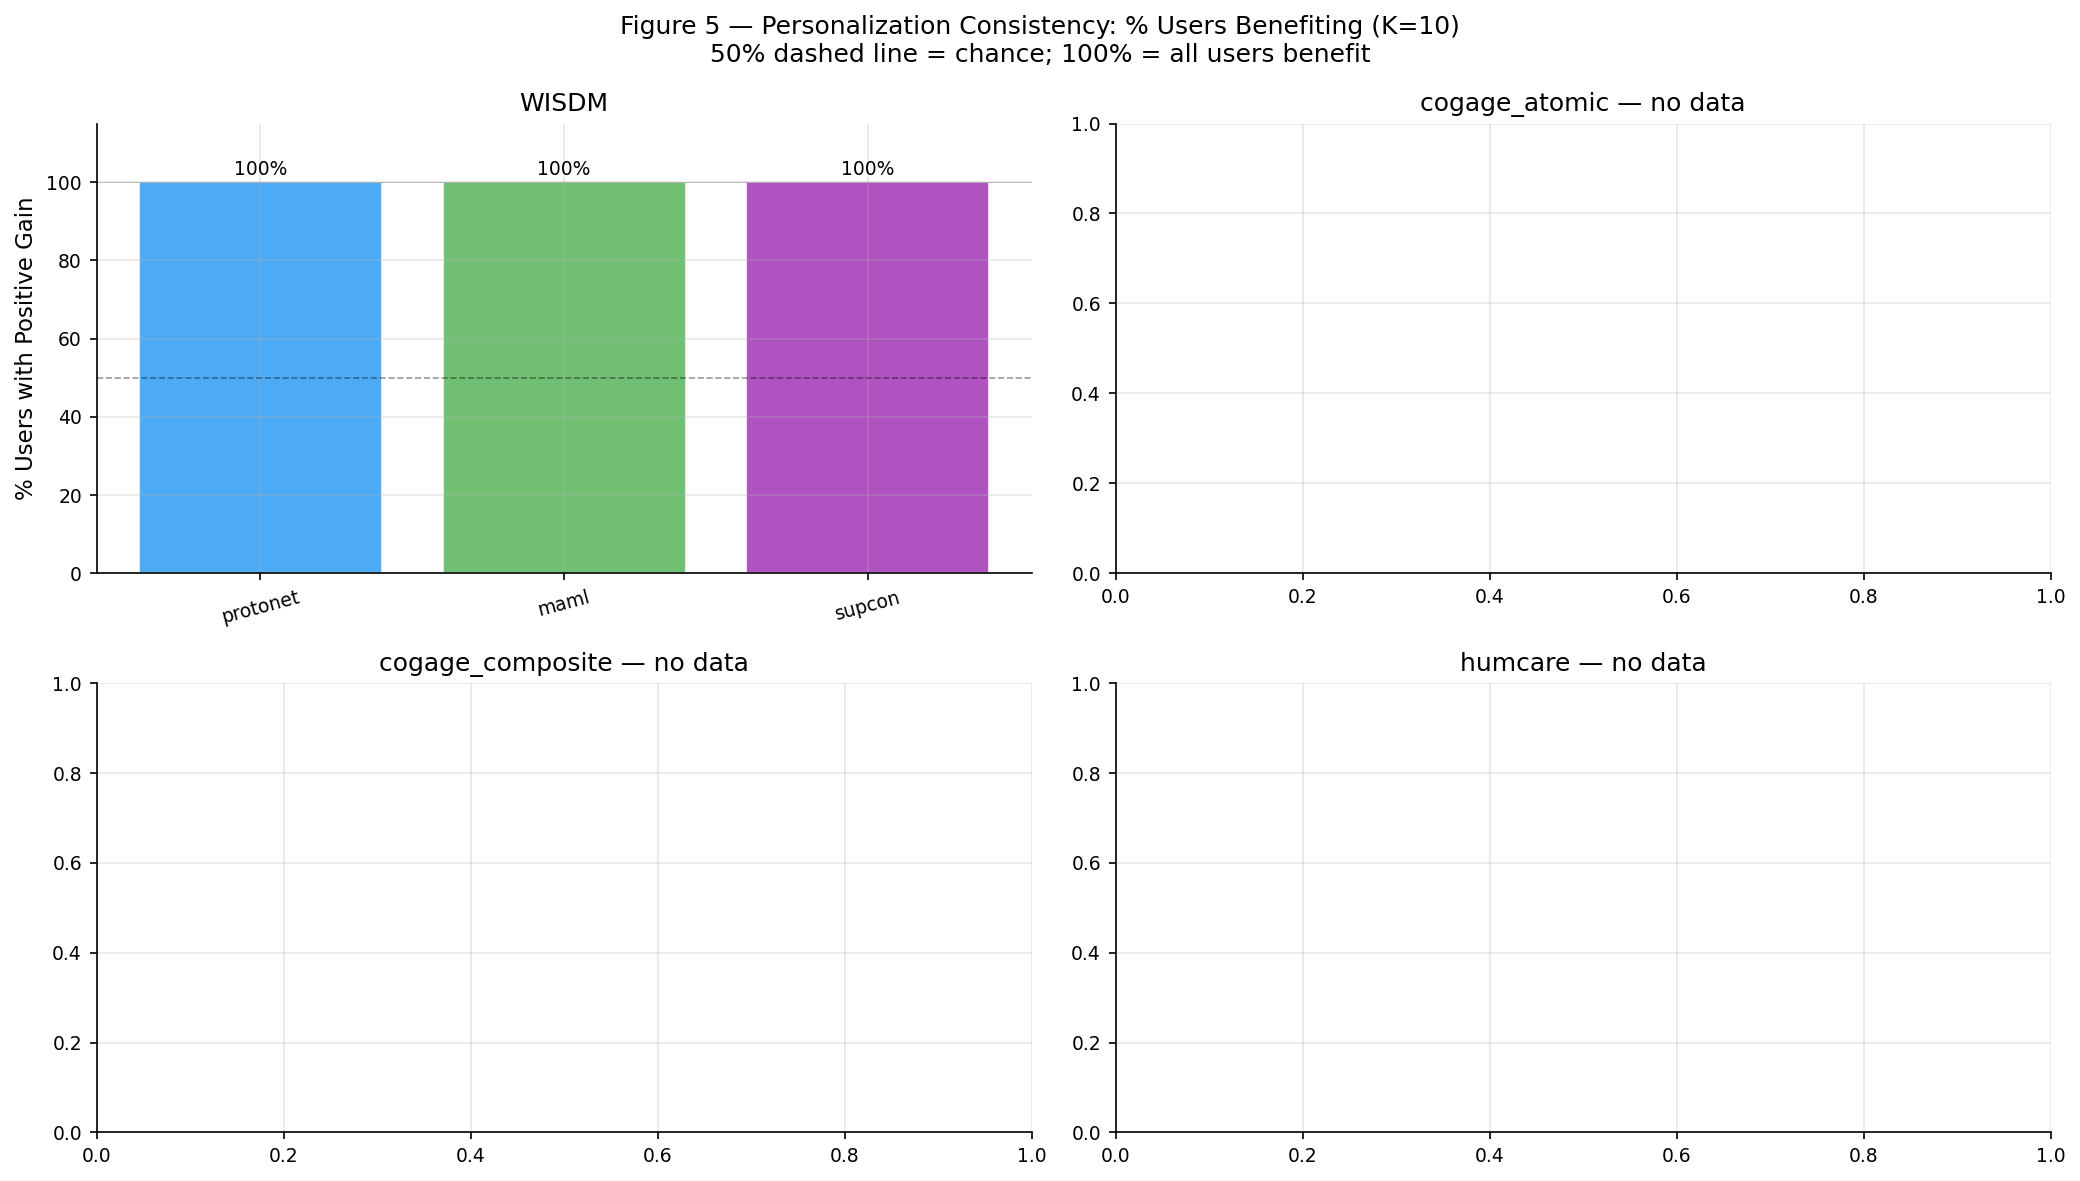

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/fig5_personalization_consistency.png


In [9]:
if df_pers.empty:
    print('No personalization data — skipping Figure 5')
else:
    sub_kmax = df_pers[df_pers['k_shot'] == K_MAX]

    # Check if we have per-user rows (multiple rows per method/backbone/dataset)
    # or aggregated rows (one row per method/backbone/dataset)
    has_per_user = 'subject' in sub_kmax.columns

    if has_per_user:
        # Per-user rows: compute fraction with positive gain
        consistency = []
        for method in avail_methods:
            for dataset in avail_datasets:
                sub = sub_kmax[
                    (sub_kmax['method']==method) &
                    (sub_kmax['dataset']==dataset)
                ]
                if len(sub) == 0: continue
                pct_positive = (sub['gain'] > 0).mean() * 100
                mean_gain    = sub['gain'].mean() * 100
                consistency.append({
                    'method' : method,
                    'dataset': dataset,
                    'pct_pos': pct_positive,
                    'mean_g' : mean_gain,
                    'n_users': len(sub),
                })
        df_cons = pd.DataFrame(consistency)

        if not df_cons.empty:
            n_ds   = len(avail_datasets)
            n_cols = min(n_ds, 2)
            n_rows = (n_ds + n_cols - 1) // n_cols

            fig, axes = plt.subplots(n_rows, n_cols,
                                     figsize=(7*n_cols, 4*n_rows),
                                     squeeze=False)

            for ax_idx, dataset in enumerate(avail_datasets):
                row, col = divmod(ax_idx, n_cols)
                ax = axes[row][col]

                sub_d = df_cons[df_cons['dataset']==dataset]
                if sub_d.empty:
                    ax.set_title(f'{dataset} — no data')
                    continue

                methods_d = sub_d['method'].tolist()
                pcts      = sub_d['pct_pos'].tolist()
                colors    = [METHOD_COLORS.get(m,'gray') for m in methods_d]

                bars = ax.bar(methods_d, pcts, color=colors, alpha=0.8, edgecolor='white')
                for bar, pct in zip(bars, pcts):
                    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                            f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)
                ax.axhline(y=50, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
                ax.axhline(y=100, color='black', linewidth=0.5, alpha=0.2)
                ax.set_ylim(0, 115)
                ax.set_ylabel('% Users with Positive Gain')
                ax.set_title(DATASET_DISPLAY_NAMES.get(dataset, dataset))
                ax.tick_params(axis='x', rotation=15)

            for ax_idx in range(len(avail_datasets), n_rows*n_cols):
                row, col = divmod(ax_idx, n_cols)
                axes[row][col].set_visible(False)

            fig.suptitle(
                f'Figure 5 — Personalization Consistency: % Users Benefiting (K={K_MAX})\n'
                '50% dashed line = chance; 100% = all users benefit',
                fontsize=12
            )
            plt.tight_layout()
            p = os.path.join(FIG_DIR, 'fig5_personalization_consistency.png')
            plt.savefig(p, dpi=150, bbox_inches='tight')
            plt.show()
            print(f'Saved: {p}')
    else:
        print('Per-user rows not found in CSV — skipping consistency figure')
        print('This figure requires notebook 13 to save per-user rows with a subject column')

## Cell 10 — Figure 6: Cross-Dataset Comparison

How does each method perform across datasets?  
Grouped bar chart: x=method, groups=dataset, bars=best backbone.

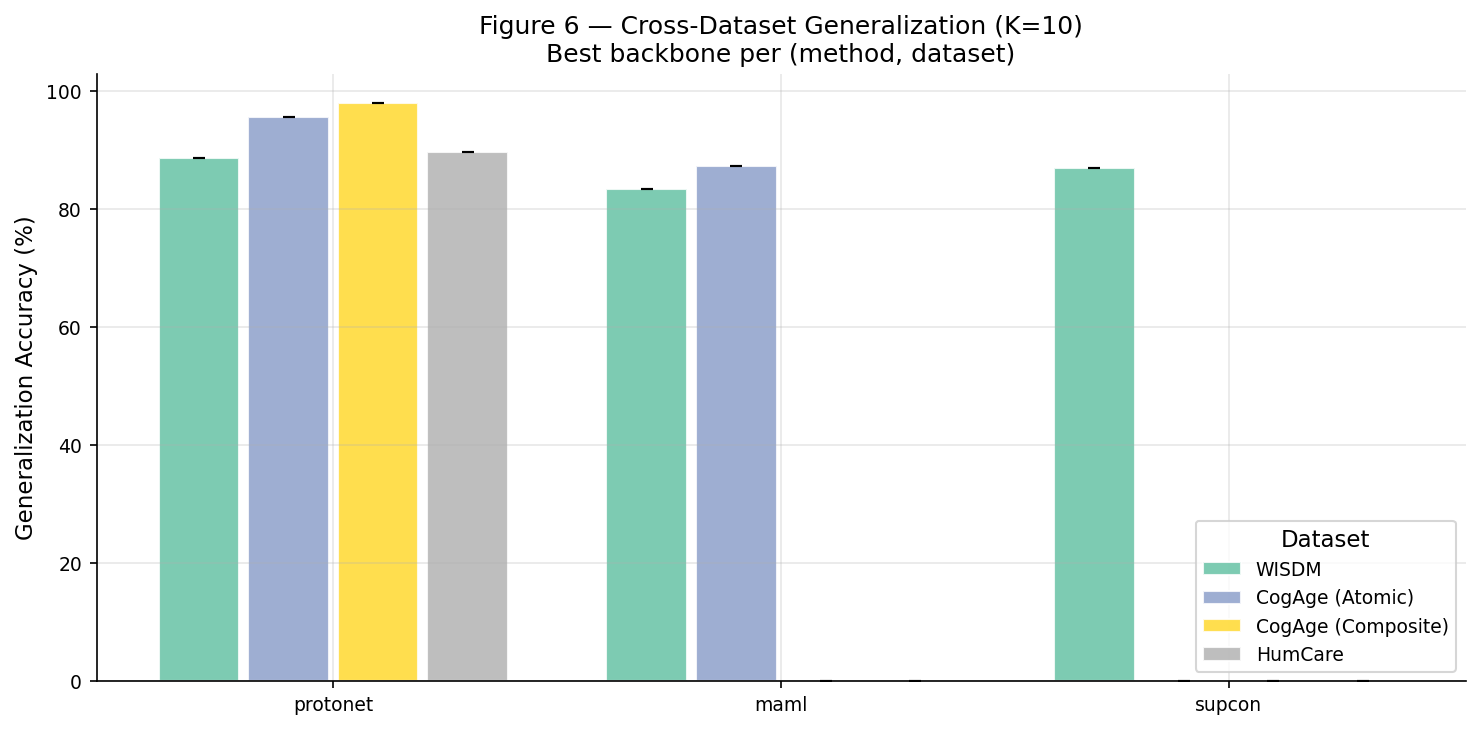

Saved: /content/drive/MyDrive/fsl_har_results/thesis_figures/fig6_cross_dataset_comparison.png


In [10]:
if df_gen.empty:
    print('No generalization data — skipping Figure 6')
elif len(avail_datasets) < 2:
    print('Need at least 2 datasets for cross-dataset comparison')
else:
    sub_kmax = df_gen[df_gen['k_shot'] == K_MAX]
    acc_col  = 'acc_mean' if 'acc_mean' in sub_kmax.columns else 'acc_after'

    # Best backbone per (method, dataset)
    best_per_md = (
        sub_kmax.groupby(['method','dataset','backbone'])[acc_col].mean()
        .reset_index()
        .sort_values(acc_col, ascending=False)
        .groupby(['method','dataset'])
        .first()
        .reset_index()
    )

    n_methods  = len(avail_methods)
    n_datasets = len(avail_datasets)
    x_pos      = np.arange(n_methods)
    width      = 0.8 / max(n_datasets, 1)
    ds_colors  = plt.cm.Set2(np.linspace(0, 1, n_datasets))

    fig, ax = plt.subplots(figsize=(max(10, n_methods*3), 5))

    for j, dataset in enumerate(avail_datasets):
        sub_d  = best_per_md[best_per_md['dataset']==dataset]
        accs   = []
        ci95s  = []
        for method in avail_methods:
            row = sub_d[sub_d['method']==method]
            if row.empty:
                accs.append(0); ci95s.append(0)
            else:
                acc  = row.iloc[0][acc_col] * 100
                ci_  = row.iloc[0].get('ci95', 0) * 100
                accs.append(acc); ci95s.append(ci_)

        offset = (j - n_datasets/2 + 0.5) * width
        ax.bar(
            x_pos + offset, accs, width*0.9,
            label=DATASET_DISPLAY_NAMES.get(dataset, dataset),
            color=ds_colors[j], alpha=0.85, edgecolor='white',
        )
        ax.errorbar(
            x_pos + offset, accs, yerr=ci95s,
            fmt='none', color='black', capsize=3, linewidth=1.2
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(avail_methods)
    ax.set_ylabel('Generalization Accuracy (%)')
    ax.set_title(
        f'Figure 6 — Cross-Dataset Generalization (K={K_MAX})\n'
        'Best backbone per (method, dataset)'
    )
    ax.legend(title='Dataset', loc='lower right')
    plt.tight_layout()
    p = os.path.join(FIG_DIR, 'fig6_cross_dataset_comparison.png')
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')

## Cell 11 — Research Question Answers

Explicit textual answers to each research question based on the results.

In [11]:
print('══ Research Question Answers ══')
print(f'   Based on available data: {len(avail_datasets)} dataset(s), '
      f'{len(avail_backbones)} backbone(s), {len(avail_methods)} method(s)')
print()

# ── RQ1: Best generalization method ───────────────────────────────────────────
print('RQ1: Which FSL method best generalizes to unseen users?')
if not df_gen.empty:
    acc_col  = 'acc_mean' if 'acc_mean' in df_gen.columns else 'acc_after'
    sub_kmax = df_gen[df_gen['k_shot'] == K_MAX]
    m_means  = sub_kmax.groupby('method')[acc_col].mean().sort_values(ascending=False)
    for method, acc in m_means.items():
        print(f'   {method:<12}: {acc*100:.2f}% mean across all datasets and backbones')
    print(f'   → Best: {m_means.idxmax()} ({m_means.max()*100:.2f}%)')
else:
    print('   → Insufficient data')

print()

# ── RQ2: Best personalization method ──────────────────────────────────────────
print('RQ2: Which FSL method best personalizes to new users?')
if not df_pers.empty:
    sub_kmax = df_pers[df_pers['k_shot'] == K_MAX]
    g_means  = sub_kmax.groupby('method')['gain'].mean().sort_values(ascending=False)
    for method, gain in g_means.items():
        print(f'   {method:<12}: {gain*100:+.2f}% mean gain')
    best_g = g_means.idxmax()
    print(f'   → Best: {best_g} ({g_means.max()*100:+.2f}% gain)')
    if g_means.max() < 0:
        print('   ⚠ All methods show negative gain — K-shot support is hurting, not helping')
        print('     Consider increasing K or checking data quality')
else:
    print('   → Insufficient data')

print()

# ── RQ3: Backbone vs method effect ────────────────────────────────────────────
print('RQ3: Does backbone choice matter more than method choice?')
if not df_gen.empty:
    sub_kmax = df_gen[df_gen['k_shot'] == K_MAX]
    acc_col  = 'acc_mean' if 'acc_mean' in sub_kmax.columns else 'acc_after'
    bb_std   = sub_kmax.groupby('backbone')[acc_col].mean().std()
    mt_std   = sub_kmax.groupby('method')[acc_col].mean().std()
    print(f'   Std of mean accuracy across backbones : {bb_std*100:.2f}%')
    print(f'   Std of mean accuracy across methods   : {mt_std*100:.2f}%')
    if bb_std > mt_std:
        print(f'   → Backbone choice has MORE variance ({bb_std/mt_std:.1f}x)')
        print(f'     Recommendation: invest in backbone architecture selection')
    else:
        print(f'   → Method choice has MORE variance ({mt_std/bb_std:.1f}x)')
        print(f'     Recommendation: invest in FSL method selection')
else:
    print('   → Insufficient data')

print()

# ── RQ4: Gen–pers trade-off ────────────────────────────────────────────────────
print('RQ4: Does the generalization→personalization trade-off hold?')
if not df_gen.empty and not df_pers.empty:
    acc_col  = 'acc_mean' if 'acc_mean' in df_gen.columns else 'acc_after'
    gen_agg  = df_gen[df_gen['k_shot']==K_MAX].groupby(['method','backbone','dataset'])[acc_col].mean().reset_index()
    pers_agg = df_pers[df_pers['k_shot']==K_MAX].groupby(['method','backbone','dataset'])['gain'].mean().reset_index()
    merged   = pd.merge(gen_agg, pers_agg, on=['method','backbone','dataset'])

    if len(merged) >= 3:
        corr, pval = scipy_stats.pearsonr(merged[acc_col], merged['gain'])
        print(f'   Pearson correlation (gen acc vs pers gain): r={corr:.3f}, p={pval:.4f}')
        if pval < 0.05:
            if corr > 0:
                print(f'   → Significant POSITIVE correlation')
                print(f'     Methods that generalize better also personalize better')
                print(f'     No fundamental trade-off detected')
            else:
                print(f'   → Significant NEGATIVE correlation')
                print(f'     Trade-off exists: generalization and personalization are competing')
        else:
            print(f'   → No significant correlation (p={pval:.3f})')
            print(f'     Generalization accuracy does not predict personalization gain')
    else:
        print(f'   → Insufficient overlapping data points ({len(merged)})')
else:
    print('   → Need both gen and pers data')

══ Research Question Answers ══
   Based on available data: 4 dataset(s), 3 backbone(s), 3 method(s)

RQ1: Which FSL method best generalizes to unseen users?
   pretrain    : 87.03% mean across all datasets and backbones
   supcon      : 86.28% mean across all datasets and backbones
   maml        : 83.22% mean across all datasets and backbones
   protonet    : 78.19% mean across all datasets and backbones
   → Best: pretrain (87.03%)

RQ2: Which FSL method best personalizes to new users?
   maml        : +31.95% mean gain
   protonet    : +24.96% mean gain
   supcon      : +23.14% mean gain
   lee         : +20.05% mean gain
   → Best: maml (+31.95% gain)

RQ3: Does backbone choice matter more than method choice?
   Std of mean accuracy across backbones : 6.02%
   Std of mean accuracy across methods   : 4.01%
   → Backbone choice has MORE variance (1.5x)
     Recommendation: invest in backbone architecture selection

RQ4: Does the generalization→personalization trade-off hold?
   Pear

## Cell 12 — Thesis Summary Text File

Writes a plain-text summary of all key numbers suitable for  
copy-pasting into the thesis discussion section.

In [12]:
summary_lines = []
def w(line=''):
    summary_lines.append(line)
    print(line)

w('══════════════════════════════════════════════════════════')
w('  THESIS RESULTS SUMMARY')
w(f'  Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
w('══════════════════════════════════════════════════════════')
w()
w('EXPERIMENT CONFIGURATION')
w(f'  Datasets   : {ALL_DATASETS}')
w(f'  Backbones  : {ALL_BACKBONES}')
w(f'  FSL Methods: {ALL_FSL_METHODS}')
w(f'  K values   : {K_SHOTS}')
w(f'  N-way eval : {DATASET_CONFIGS[ALL_DATASETS[0]]["n_way"]} (varies by dataset)')
w(f'  Master seed: {MASTER_SEED}')
w()
w(f'DATA AVAILABLE IN THIS SUMMARY')
w(f'  Datasets with gen results  : {avail_datasets}')
w(f'  Datasets with pers results : {[d for d in ALL_DATASETS if any(df_pers["dataset"]==d)] if not df_pers.empty else []}')
w()

if not df_gen.empty:
    w('GENERALIZATION RESULTS (K=10)')
    acc_col = 'acc_mean' if 'acc_mean' in df_gen.columns else 'acc_after'
    sub_kmax = df_gen[df_gen['k_shot']==K_MAX]
    for dataset in avail_datasets:
        w(f'  {dataset}:')
        sub_ds = sub_kmax[sub_kmax['dataset']==dataset]
        for method in avail_methods:
            sub_m = sub_ds[sub_ds['method']==method]
            if sub_m.empty: continue
            for backbone in avail_backbones:
                sub_b = sub_m[sub_m['backbone']==backbone]
                if sub_b.empty: continue
                acc  = sub_b.iloc[0][acc_col]
                ci95 = sub_b.iloc[0].get('ci95', 0)
                w(f'    {method:<12} + {backbone:<12}: {acc*100:.2f}% ±{ci95*100:.2f}%')
    w()

if not df_pers.empty:
    w('PERSONALIZATION GAIN RESULTS (K=10)')
    sub_kmax = df_pers[df_pers['k_shot']==K_MAX]
    for dataset in avail_datasets:
        sub_ds = sub_kmax[sub_kmax['dataset']==dataset]
        if sub_ds.empty: continue
        w(f'  {dataset}:')
        for method in avail_methods:
            sub_m = sub_ds[sub_ds['method']==method]
            if sub_m.empty: continue
            for backbone in avail_backbones:
                sub_b = sub_m[sub_m['backbone']==backbone]
                if sub_b.empty: continue
                gain = sub_b['gain'].mean()
                ci95 = (sub_b['ci95'].mean() if 'ci95' in sub_b.columns
                        else 1.96*sub_b['gain'].std()/max(np.sqrt(len(sub_b)),1))
                sign = '+' if gain >= 0 else ''
                w(f'    {method:<12} + {backbone:<12}: gain={sign}{gain*100:.2f}% ±{ci95*100:.2f}%')
    w()

w('FIGURES SAVED')
for fname in sorted(os.listdir(FIG_DIR)):
    if fname.endswith('.png') or fname.endswith('.csv'):
        w(f'  {fname}')
w()
w('══════════════════════════════════════════════════════════')

summary_path = os.path.join(FIG_DIR, 'thesis_summary.txt')
with open(summary_path, 'w') as f:
    f.write('\n'.join(summary_lines))
print(f'\nSaved: {summary_path}')

══════════════════════════════════════════════════════════
  THESIS RESULTS SUMMARY
  Generated: 2026-05-01 16:38
══════════════════════════════════════════════════════════

EXPERIMENT CONFIGURATION
  Datasets   : ['wisdm', 'cogage_atomic', 'cogage_composite', 'humcare']
  Backbones  : ['cnn', 'lstm', 'transformer']
  FSL Methods: ['protonet', 'lee', 'maml', 'supcon']
  K values   : [1, 5, 10]
  N-way eval : 5 (varies by dataset)
  Master seed: 42

DATA AVAILABLE IN THIS SUMMARY
  Datasets with gen results  : ['wisdm', 'cogage_atomic', 'cogage_composite', 'humcare']
  Datasets with pers results : ['wisdm', 'cogage_atomic', 'cogage_composite', 'humcare']

GENERALIZATION RESULTS (K=10)
  wisdm:
    protonet     + cnn         : 88.51% ±1.07%
    protonet     + lstm        : 1.08% ±nan%
    protonet     + transformer : 1.18% ±nan%
    maml         + cnn         : 83.28% ±1.25%
    maml         + lstm        : 81.31% ±1.22%
    maml         + transformer : 81.22% ±1.34%
    supcon       + c

## Cell 13 — Complete Figure Inventory

In [13]:
print('══ All Thesis Outputs ══')
print(f'   Directory: {FIG_DIR}')
print()

files = sorted(os.listdir(FIG_DIR))
for fname in files:
    fpath   = os.path.join(FIG_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1000
    ext     = fname.split('.')[-1].upper()
    desc    = {
        'fig1_kshot_generalization.png'     : 'K-shot curves, all methods × datasets',
        'fig2_gain_heatmap.png'             : 'Personalization gain heatmap',
        'fig3_backbone_vs_method_effect.png': 'Backbone vs method effect (RQ3)',
        'fig4_gen_vs_pers_tradeoff.png'     : 'Gen vs pers scatter (RQ4)',
        'fig5_personalization_consistency.png': '% users benefiting from personalization',
        'fig6_cross_dataset_comparison.png' : 'Cross-dataset generalization comparison',
        'table_generalization.csv'          : 'Full generalization results table',
        'table_personalization.csv'         : 'Full personalization gain table',
        'thesis_summary.txt'                : 'Plain-text key numbers summary',
    }.get(fname, 'Additional output')
    print(f'   {"[" + ext + "]":>8}  {fname:<50}  {size_kb:>7.1f} KB  — {desc}')

print()
print('══ NOTEBOOK PIPELINE COMPLETE ══')
print()
print('  Notebooks completed: 00 → 01 → 02 → 03 → 04')
print('                    → 05 → 06 → 07')
print('                    → 08 → 09 → 10 → 11')
print('                    → 12 → 13 → 14 → 15  ✅')
print()
print('  4 datasets × 3 backbones × 4 FSL methods = 48 configurations')
print('  Generalization and personalization evaluated at K = 1, 5, 10')
print()
print('  All results, figures, and tables saved to:')
print(f'  {RESULTS_BASE}')

══ All Thesis Outputs ══
   Directory: /content/drive/MyDrive/fsl_har_results/thesis_figures

      [PNG]  fig1_kshot_generalization.png                         174.4 KB  — K-shot curves, all methods × datasets
      [PNG]  fig2_gain_heatmap.png                                  68.0 KB  — Personalization gain heatmap
      [PNG]  fig3_backbone_vs_method_effect.png                     76.3 KB  — Backbone vs method effect (RQ3)
      [PNG]  fig4_gen_vs_pers_tradeoff.png                         115.0 KB  — Gen vs pers scatter (RQ4)
      [PNG]  fig5_personalization_consistency.png                   94.8 KB  — % users benefiting from personalization
      [PNG]  fig6_cross_dataset_comparison.png                      60.2 KB  — Cross-dataset generalization comparison
      [CSV]  table_generalization.csv                                4.6 KB  — Full generalization results table
      [CSV]  table_personalization.csv                               2.5 KB  — Full personalization gain table
   